For the EGFR pathway, get all genes associated using steiner graph of human PPI. 

Measure the transcriptome shift in low vs high scores - both miniFORGE and allFORGE

Compare results across the drug concentrations

In [ ]:
# %pip install networkx

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from networkx.algorithms.approximation import steiner_tree
%matplotlib inline

In [2]:
import requests

# KEGG pathways
query_pathways = ['hsa00760'] # Nicotinate and nicotinamide metabolism

total_genes = []
for path_id in query_pathways:
    url = f"https://rest.kegg.jp/link/hsa/pathway:{path_id}"
    response = requests.get(url)

    genes = sorted({
        line.split("\t")[1].replace("hsa:", "")
        for line in response.text.strip().split("\n")
    })
    total_genes.extend(genes)
total_genes = list(set(total_genes))
print(f"Total unique genes from KEGG pathways: {len(total_genes)}")
nampt_pathway_genes = total_genes[:]

Total unique genes from KEGG pathways: 38


In [3]:
import requests

# KEGG pathways
query_pathways = ['hsa00760', 'hsa04621'] # nod-like receptor signalling
total_genes = []
for path_id in query_pathways:
    url = f"https://rest.kegg.jp/link/hsa/pathway:{path_id}"
    response = requests.get(url)

    genes = sorted({
        line.split("\t")[1].replace("hsa:", "")
        for line in response.text.strip().split("\n")
    })
    total_genes.extend(genes)
total_genes = list(set(total_genes))
print(f"Total unique genes from KEGG pathways: {len(total_genes)}")

Total unique genes from KEGG pathways: 226


In [4]:
# get DAPORINAD-NAMPT gene weights df
from forge_class_instance3 import FORGE
nampt_dapo_model = FORGE.load_forge(path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Models/daporinad_new_splits/DAPORINAD_NAMPT_forgeModel_rankedHP_321456.pkl')
dep_imp = nampt_dapo_model.W @ nampt_dapo_model.hD
ic50_imp = nampt_dapo_model.W @ nampt_dapo_model.hI

/home/sreeramp/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
gene_weights_df = pd.DataFrame({'dep_imp': dep_imp.ravel(), 'ic50_imp': ic50_imp.ravel()},
                           index = nampt_dapo_model.hcg_list)
gene_weights_df.head()

,dep_imp,ic50_imp
ZNF852,-0.020094,0.377832
FERMT2,0.025394,0.034180
BLMH,-0.015531,-0.173248
SEMA4D,0.016402,0.055525
HNRNPA1,-0.000808,-0.067584


In [6]:
gene_weights_df['combined'] = gene_weights_df['dep_imp'] - gene_weights_df['ic50_imp']
gene_weights_df['scaled_combined'] = (gene_weights_df['combined'] - np.mean(gene_weights_df['ic50_imp'])) / np.std(gene_weights_df['ic50_imp'])
gene_weights_df.head()                                  

,dep_imp,ic50_imp,combined,scaled_combined
ZNF852,-0.020094,0.377832,-0.397926,-1.841127
FERMT2,0.025394,0.034180,-0.008786,-0.111195
BLMH,-0.015531,-0.173248,0.157718,0.629000
SEMA4D,0.016402,0.055525,-0.039123,-0.246060
HNRNPA1,-0.000808,-0.067584,0.066775,0.224714


In [7]:
gene_weights_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/NAMPT_DAPORINAD_geneImp_optuna.csv', index=True)
gene_weights_df.head()

,dep_imp,ic50_imp,combined,scaled_combined
ZNF852,-0.020094,0.377832,-0.397926,-1.841127
FERMT2,0.025394,0.034180,-0.008786,-0.111195
BLMH,-0.015531,-0.173248,0.157718,0.629000
SEMA4D,0.016402,0.055525,-0.039123,-0.246060
HNRNPA1,-0.000808,-0.067584,0.066775,0.224714


In [3]:
gene_weights_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/NAMPT_DAPORINAD_geneImp_optuna.csv', header = 0, index_col=0)
gene_weights_df.head()

,dep_imp,ic50_imp,combined,scaled_combined
ZNF852,-0.020094,0.377832,-0.397926,-1.841127
FERMT2,0.025394,0.034180,-0.008786,-0.111195
BLMH,-0.015531,-0.173248,0.157718,0.629000
SEMA4D,0.016402,0.055525,-0.039123,-0.246060
HNRNPA1,-0.000808,-0.067584,0.066775,0.224714


In [8]:
total_genes.extend(gene_weights_df.index.tolist())
total_genes = list(set(total_genes))
print(f"Final genes for steiner graph: {len(total_genes)}")

Final genes for steiner graph: 424


In [4]:
# load the aliases file for mapping ids
aliases_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/hsapiens_aliases.txt', sep = '\t')
aliases_df.head()

,#string_protein_id,alias,source
0,9606.ENSP00000000233,2B6H,Ensembl_PDB
1,9606.ENSP00000000233,2B6H,UniProt_DR_PDB
2,9606.ENSP00000000233,381,Ensembl_HGNC_entrez_id
3,9606.ENSP00000000233,381,KEGG_GENEID
4,9606.ENSP00000000233,381,KEGG_KEGGID_SHORT


In [10]:
alias_ensp_map = dict(zip(aliases_df['alias'], aliases_df['#string_protein_id']))

In [11]:
aliases_names = aliases_df['alias'].unique()
missing_ids = [i for i in total_genes if i not in aliases_names]
len(missing_ids)

18

In [12]:
missing_ids

['NAMPTP1',
 'RPSAP52',
 'PRADX',
 '124906748',
 'WWTR1-AS1',
 'TGILR',
 'P4HA2-AS1',
 'ARHGEF34P',
 'MIR22HG',
 'NEXN-AS1',
 'RFX5-AS1',
 '392288',
 '107181291',
 'MIR100HG',
 '124906744',
 '100506742',
 'BTNL12P',
 '5602']

In [13]:
total_genes_mapped = [alias_ensp_map[g] for g in total_genes if g in alias_ensp_map]
len(total_genes_mapped)

406

In [14]:
total_genes_mapped[:5]

['9606.ENSP00000303532',
 '9606.ENSP00000376849',
 '9606.ENSP00000211287',
 '9606.ENSP00000342385',
 '9606.ENSP00000324633']

In [15]:
# some additional genes
genes_with_ensembl = [
    ("NAMPTP1",     "ENSG00000229644"),
    ("RPSAP52",     "ENSG00000241749"),
    ("PRADX",       "ENSG00000235027"),
    ("WWTR1-AS1",   "ENSG00000241313"),
    ("TGILR",       "ENSG00000260604"),
    ("P4HA2-AS1",   "ENSG00000237714"),
    ("MIR22HG",     "ENSG00000282800"),
    ("NEXN-AS1",    "ENSG00000235927"),
    ("RFX5-AS1",    "ENSG00000237976"),
    ("MIR100HG",    "ENSG00000255248"),
    ("BTNL12P",     "ENSG00000240661"),
    ("PYDC5",       "ENSG00000289721"),
    ("MAPK10",      "ENSG00000109339"),
    ("CASP12",      "ENSG00000204403"),
]

total_genes.extend([g[0] for g in genes_with_ensembl])
total_genes.extend([g[1] for g in genes_with_ensembl])
total_genes = list(set(total_genes))

In [16]:
string_api_url = "https://version-12-0.string-db.org/api"
output_format = "tsv-no-header"
method = "network"

##
## Construct URL
##

request_url = "/".join([string_api_url, output_format, method])

##
## Set parameters
## dont set a cutoff here
##
params = {

    "identifiers" : "%0d".join(total_genes_mapped), # your protein
    "species" : 9606, # NCBI/STRING taxon identifier 
    "caller_identity" : "srirambds.murthy@gmail.com" # your app name

}

##
## Call STRING
##

response = requests.post(request_url, data=params)

In [17]:
total_genes_from_string_v1 = []
for line in response.text.strip().split("\n"):

    l = line.strip().split("\t")
    p1, p2 = l[2], l[3]
    total_genes_from_string_v1.extend([p1,p2])
total_genes_from_string_v1 = list(set(total_genes_from_string_v1))

In [18]:
len(total_genes_from_string_v1)

367

In [19]:
string_api_url = "https://version-12-0.string-db.org/api"
output_format = "tsv-no-header"
method = "interaction_partners"

##
## Construct the request
##

request_url = "/".join([string_api_url, output_format, method])

##
## Set parameters
##

params = {

    "identifiers" : "%0d".join(total_genes_from_string_v1), # your protein
    "species" : 9606, # NCBI/STRING taxon identifier,
    "limit": 10,
    "required_score" : 700, # high confidence interactions only (medium gave > 2500 genes)
    "caller_identity" : "srirambds.murthy@gmail.com" # your app name

}


##
## Call STRING
##

response2 = requests.post(request_url, data=params)


In [20]:
total_genes_from_string_v2 = []
for line in response2.text.strip().split("\n"):

    l = line.strip().split("\t")
    p1, p2 = l[2], l[3]
    total_genes_from_string_v2.extend([p1,p2])
total_genes_from_string_v2 = list(set(total_genes_from_string_v2))
len(total_genes_from_string_v2)

1742

In [21]:
total_genes_from_string_v2[:10]

['TUBA3D',
 'TPD52L2',
 'BMP1',
 'REL',
 'TNFRSF25',
 'MAP2K3',
 'BOD1L1',
 'RANBP10',
 'BCAR1',
 'PTGES']

In [22]:
with open('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/nampt_daporinad_steiner_input.txt', 'w') as f:
  f.write("\n".join(total_genes_from_string_v2))

### Get Stiener graph from the above gene list

In [1]:
import networkx as nx

In [2]:
full_ppi = nx.read_graphml('/home/sreeramp/cancer_dependency_project/sreeram/network_analysis/human_proteome_full_links.graphml')

In [3]:
full_ppi.number_of_nodes(), full_ppi.number_of_edges()

(19622, 6857702)

In [24]:
sum(gene in full_ppi.nodes() for gene in total_genes_from_string_v2)

1742

In [25]:
any(gene not in full_ppi.nodes() for gene in total_genes_from_string_v2)

False

In [26]:
import sys
from pathlib import Path

MODULE_PATH = Path("/home/sreeramp/cancer_dependency_project/sreeram/matrix_factorisation")
sys.path.insert(0, str(MODULE_PATH))

from computeStienerGraph import compute_steiner_subgraph


In [27]:
compute_steiner_subgraph(fullPPI=full_ppi, terminal_nodes=total_genes_from_string_v2, n_iter=50, rand_prop=0.8, label='steiner_NAMPT_DAPO', save_path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data', seed=198716)


▶ Starting Steiner tree computation for: steiner_NAMPT_DAPO
 - Terminal candidates available: 1742
 - Terminals per iteration: 1393
 - Total iterations: 50
   ✔ Completed iteration 10/50
   ✔ Completed iteration 20/50
   ✔ Completed iteration 30/50
   ✔ Completed iteration 40/50
   ✔ Completed iteration 50/50
✅ Final Steiner tree for steiner_NAMPT_DAPO saved to: /home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/steiner_NAMPT_DAPO_steinerTree.graphml



### reload the steiner graph and probe it

In [5]:
steiner_graph_new = nx.read_graphml(path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/steiner_NAMPT_DAPO_steinerTree.graphml')
steiner_graph_new.number_of_nodes()

1743

In [29]:
target_gene = 'NAMPT'
nx.single_source_all_shortest_paths(G=steiner_graph_new, source = target_gene)

<generator object single_source_all_shortest_paths at 0x7f2ccfffe680>

In [30]:
p = dict(nx.single_source_all_shortest_paths(G=steiner_graph_new, source = target_gene))

In [31]:
p

{'NAMPT': [['NAMPT']],
 'CGAS': [['NAMPT', 'CGAS']],
 'NTRK1': [['NAMPT', 'NTRK1']],
 'EREG': [['NAMPT', 'EREG']],
 'CDK2': [['NAMPT', 'CDK2']],
 'PYCR3': [['NAMPT', 'PYCR3']],
 'APP': [['NAMPT', 'CGAS', 'APP']],
 'EMD': [['NAMPT', 'CGAS', 'EMD']],
 'MUC1': [['NAMPT', 'CGAS', 'MUC1']],
 'B4E171_HUMAN': [['NAMPT', 'CGAS', 'B4E171_HUMAN']],
 'PPIF': [['NAMPT', 'CGAS', 'PPIF']],
 'CD34': [['NAMPT', 'CGAS', 'CD34']],
 'AZI2': [['NAMPT', 'CGAS', 'AZI2']],
 'BCL3': [['NAMPT', 'CGAS', 'BCL3']],
 'DIABLO-2': [['NAMPT', 'NTRK1', 'DIABLO-2']],
 'UNC5C': [['NAMPT', 'NTRK1', 'UNC5C']],
 'BAD': [['NAMPT', 'NTRK1', 'BAD']],
 'UBE2D2': [['NAMPT', 'NTRK1', 'UBE2D2']],
 'MIEF1': [['NAMPT', 'NTRK1', 'MIEF1']],
 'PKP4': [['NAMPT', 'NTRK1', 'PKP4']],
 'SNAPIN': [['NAMPT', 'NTRK1', 'SNAPIN']],
 'MEFV': [['NAMPT', 'EREG', 'MEFV']],
 'TRPM6': [['NAMPT', 'EREG', 'TRPM6']],
 'MAPK14': [['NAMPT', 'EREG', 'MAPK14']],
 'SCARB2': [['NAMPT', 'EREG', 'SCARB2']],
 'ATG4A': [['NAMPT', 'CDK2', 'ATG4A']],
 'ERBB4': [['N

In [33]:
records = []

for target_node, paths in p.items():
    
    # All paths are shortest paths → take the first as representative
    shortest_path = paths[0]
    
    # Distance = number of edges
    shortest_dist = len(shortest_path) - 1

    records.append({
        "node": target_node,
        "NAMPT_n_shortest_paths": len(paths),
        "NAMPT_shortest_dist": shortest_dist,
        "NAMPT_shortest_path": ":".join(shortest_path)
    })

path_dists_df = (
    pd.DataFrame(records)
    .set_index("node")
)

In [34]:
path_dists_df.head()

,NAMPT_n_shortest_paths,NAMPT_shortest_dist,NAMPT_shortest_path
node,,,
NAMPT,1,0,NAMPT
CGAS,1,1,NAMPT:CGAS
NTRK1,1,1,NAMPT:NTRK1
EREG,1,1,NAMPT:EREG
CDK2,1,1,NAMPT:CDK2


In [35]:
path_dists_df.loc[path_dists_df['NAMPT_shortest_dist'] == 3,:].shape

(144, 3)

In [36]:
path_dists_df['NAMPT_shortest_dist'].describe()

count    1743.000000
mean        4.584050
std         0.892447
min         0.000000
25%         4.000000
50%         5.000000
75%         5.000000
max         6.000000
Name: NAMPT_shortest_dist, dtype: float64

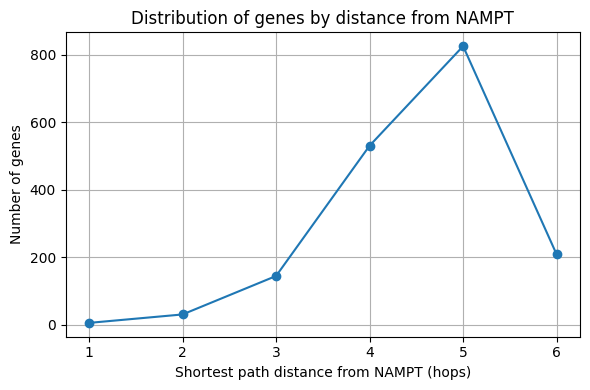

In [37]:
# Ensure numeric
path_dists_df['NAMPT_shortest_dist'] = path_dists_df['NAMPT_shortest_dist'].astype(int)

# Count nodes per distance
dist_counts = (
    path_dists_df
    .loc[path_dists_df['NAMPT_shortest_dist'] >= 1, 'NAMPT_shortest_dist']
    .value_counts()
    .sort_index()
)

# Line plot
plt.figure(figsize=(6, 4))
plt.plot(dist_counts.index, dist_counts.values, marker='o')
plt.xlabel("Shortest path distance from NAMPT (hops)")
plt.ylabel("Number of genes")
plt.title("Distribution of genes by distance from NAMPT")
plt.grid(True)
plt.tight_layout()
plt.show()

In [39]:
ranked_closest_genes = path_dists_df.loc[path_dists_df['NAMPT_shortest_dist'] <= 3, :].index
len(ranked_closest_genes)

180

In [ ]:
# compute steiner graph of these 375 genes
compute_steiner_subgraph(fullPPI=steiner_graph_new, terminal_nodes=ranked_closest_genes, n_iter=50, rand_prop=0.8, label='steiner_highConfidence_closest', save_path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data', seed=198716)

Add pseudo-edges based on shared unique neighbors

In [ ]:
# # get nodes with high degrees
# closest_graph = nx.read_graphml('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/steiner_highConfidence_closest_EGFR_steinerTree.graphml')
# closest_graph.number_of_nodes()

In [ ]:
# node_degrees = dict(closest_graph.degree())
# hub_nodes = [i for i in node_degrees.keys() if node_degrees[i] >= 10]
# len(hub_nodes)

In [ ]:
# hub_nodes

In [6]:
# RWR algo
def random_walk_with_restart(
    G,
    hubs,
    restart_prob=0.4,
    weight=None,
    tol=1e-9,
    max_iter=1000
):
    """
    Random Walk with Restart (RWR) on a NetworkX graph.

    Parameters
    ----------
    G : networkx.Graph
        Undirected or directed graph.
    hubs : list or set
        Seed nodes (e.g., hub genes).
    restart_prob : float
        Restart probability r (typically 0.3–0.5).
    weight : str or None
        Edge attribute to use as weight; None for unweighted.
    tol : float
        Convergence tolerance (L1 norm).
    max_iter : int
        Maximum number of iterations.

    Returns
    -------
    dict
        {node: steady_state_probability}
    """

    # --- Build row-stochastic transition matrix ---
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    n = len(nodes)

    P = np.zeros((n, n))
    for u in nodes:
        i = idx[u]
        neighbors = G[u]
        total = 0.0
        for v, attrs in neighbors.items():
            total += attrs.get(weight, 1.0)
        if total == 0:
            continue
        for v, attrs in neighbors.items():
            j = idx[v]
            P[i, j] = attrs.get(weight, 1.0) / total

    # --- Seed (restart) vector ---
    p0 = np.zeros(n)
    hub_set = set(hubs)
    for i, node in enumerate(nodes):
        if node in hub_set:
            p0[i] = 1.0

    if p0.sum() == 0:
        raise ValueError("None of the hub genes are present in the graph")

    p0 /= p0.sum()

    # --- Power iteration ---
    p = p0.copy()
    for _ in range(max_iter):
        p_next = (1 - restart_prob) * p @ P + restart_prob * p0
        if np.linalg.norm(p_next - p, 1) < tol:
            break
        p = p_next

    return dict(zip(nodes, p))


# ---------------- Example usage ----------------
# hub_genes = hub_nodes
# rwr_scores = random_walk_with_restart(
#     G=closest_graph,
#     hubs=hub_genes,
#     restart_prob=0.4,
#     weight="weight"  # or None if unweighted
# )
# nx.set_node_attributes(closest_graph, rwr_scores, "RWR")


In [41]:
# compute hub genes from 2400 steiner graph
node_degrees = dict(steiner_graph_new.degree())

In [7]:
# hub_genes = [i for i in steiner_graph_new.nodes() if node_degrees[i] >= 10]
rwr_scores = random_walk_with_restart(
    G=steiner_graph_new,
    hubs=['NAMPT'], max_iter = 1000000,
    restart_prob=0.4,
    weight="weight"  # or None if unweighted
)
# nx.set_node_attributes(closest_graph, rwr_scores, "RWR")

In [8]:
rwr_scores

{'NDUFV2': np.float64(1.0203037797898709e-05),
 'TUBA3D': np.float64(0.00019491189354414284),
 'TPD52L2': np.float64(8.45764403810046e-06),
 'NLRC5': np.float64(0.00037415879056551895),
 'BMP1': np.float64(6.597525214534827e-05),
 'AREG': np.float64(2.5541748990301812e-05),
 'ATXN2': np.float64(0.0005568267426276686),
 'REL': np.float64(2.3468157905641182e-05),
 'HSPA5': np.float64(0.0009584569796745655),
 'TNFRSF25': np.float64(1.840330800513583e-05),
 'MAP2K3': np.float64(0.00036519287881968903),
 'RANBP10': np.float64(8.207326038675326e-06),
 'BCAR1': np.float64(2.3956901221208987e-05),
 'PTGES': np.float64(0.0004087443133747375),
 'PNP': np.float64(6.040796153802898e-05),
 'NRP1': np.float64(3.787147449279637e-05),
 'TIFA': np.float64(1.9255026387627504e-05),
 'IRF5': np.float64(3.971637982638071e-05),
 'ARID1B': np.float64(8.092615536125867e-06),
 'MALT1': np.float64(5.252273597068752e-06),
 'RPS3A': np.float64(0.0003267822152426602),
 'GPKOW': np.float64(4.544286550839303e-05),
 

In [9]:
rwr_series = pd.Series(rwr_scores)
rwr_series.head()

NDUFV2     0.000010
TUBA3D     0.000195
TPD52L2    0.000008
NLRC5      0.000374
BMP1       0.000066
dtype: float64

In [10]:
rwr_series.sum()

np.float64(1.0)

In [11]:
import mygene
mg = mygene.MyGeneInfo()

In [12]:
kegg_genes = []
unique_aliases = aliases_df['alias'].unique()
for g in nampt_pathway_genes:

    rows = aliases_df.loc[
        (aliases_df['source'] == 'KEGG_GENEID') &
        (aliases_df['alias'] == str(g)),
        '#string_protein_id'
    ]

    if rows.empty:
        print(f"⚠️ No STRING protein for KEGG gene {g}")
        continue

    for sid in rows.values:
        ensp_id = sid.replace('9606.', '')
        print(g, ensp_id)
        res = mg.query(
            ensp_id,
            scopes="ensembl.protein",
            fields="symbol,name,entrezgene",
            species="human")
    # print(res)
        if res['hits']:
            alias = res['hits'][0]['symbol']
            kegg_genes.append(alias)


Input sequence provided is already in string format. No operation performed


23057 ENSP00000287713


Input sequence provided is already in string format. No operation performed


⚠️ No STRING protein for KEGG gene 65220
5167 ENSP00000498074


Input sequence provided is already in string format. No operation performed


...

54981 ENSP00000366007


Input sequence provided is already in string format. No operation performed


93100 ENSP00000401508


Input sequence provided is already in string format. No operation performed


⚠️ No STRING protein for KEGG gene 349565
683 ENSP00000265016


In [13]:
len(kegg_genes)

36

In [14]:
rwr_prob_df = pd.DataFrame(rwr_series, columns=['rwr_prob'])
rwr_prob_df['gene'] = rwr_prob_df.index
rwr_prob_df['NAMPT_KEGG'] = np.where(rwr_prob_df['gene'].isin(kegg_genes), 'yes', 'no')
rwr_prob_df['FORGE_HCG'] = np.where(rwr_prob_df['gene'].isin(gene_weights_df.index), 'yes', 'no')
rwr_prob_df.head()

,rwr_prob,gene,NAMPT_KEGG,FORGE_HCG
NDUFV2,0.000010,NDUFV2,no,no
TUBA3D,0.000195,TUBA3D,no,no
TPD52L2,0.000008,TPD52L2,no,no
NLRC5,0.000374,NLRC5,no,no
BMP1,0.000066,BMP1,no,no


In [15]:
rwr_prob_df.head()

,rwr_prob,gene,NAMPT_KEGG,FORGE_HCG
NDUFV2,0.000010,NDUFV2,no,no
TUBA3D,0.000195,TUBA3D,no,no
TPD52L2,0.000008,TPD52L2,no,no
NLRC5,0.000374,NLRC5,no,no
BMP1,0.000066,BMP1,no,no


In [16]:
rwr_prob_df.to_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/NAMPT_DAPO_RWR_PROBS.CSV', index=True)

In [17]:
pd.crosstab(rwr_prob_df['FORGE_HCG'], rwr_prob_df['NAMPT_KEGG'])

NAMPT_KEGG,no,yes
FORGE_HCG,,
no,1565,32
yes,144,2


In [18]:
top_rwr_genes = rwr_series.sort_values(ascending=False).head(20).index
top_rwr = rwr_series.loc[top_rwr_genes]
top_rwr

NAMPT       0.428594
NTRK1       0.055326
CDK2        0.055296
PYCR3       0.055138
CGAS        0.054455
EREG        0.054085
RPS15       0.011791
UPP1        0.011776
MAPK14      0.007506
MEFV        0.007300
SCARB2      0.007196
TRPM6       0.007024
UBE2D2      0.004626
PPIF        0.004605
SNAPIN      0.004603
PKP4        0.004536
UNC5C       0.004491
BCL3        0.004482
DIABLO-2    0.004460
MIEF1       0.004427
dtype: float64

In [19]:
subset_terminal_nodes = list(top_rwr_genes.names)
subset_terminal_nodes.extend(kegg_genes)
subset_terminal_nodes = list(set(subset_terminal_nodes))

In [20]:
len(subset_terminal_nodes)

37

In [21]:
compute_steiner_subgraph(fullPPI=steiner_graph_new, terminal_nodes=subset_terminal_nodes, n_iter=50, rand_prop=0.8, label='NAMPT_rwr_highConf', save_path='/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data', seed=198716)

NameError: name 'compute_steiner_subgraph' is not defined

#### create venn diagram of gene lists

In [22]:
steiner_rwr_graph = nx.read_graphml('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/NAMPT_rwr_highConf_steinerTree.graphml')

In [23]:
stiener_nodes = list(steiner_rwr_graph.nodes())

In [24]:
gene_imp_df = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_ERLOTINIB_geneImp_optuna.csv', header = 0, index_col = 0)
hcg_list = gene_imp_df.index

In [25]:
len(stiener_nodes), len(hcg_list), len(kegg_genes), steiner_graph_new.number_of_nodes()

(123, 201, 36, 1743)

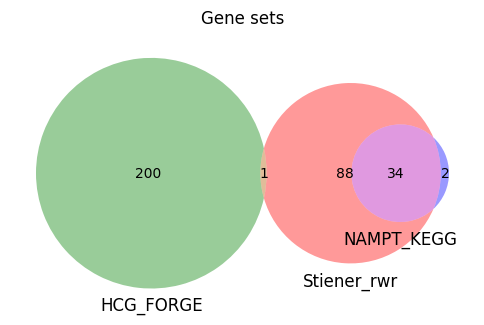

In [26]:
from matplotlib_venn import venn3

plt.figure(figsize=(6, 6))
venn3([set(stiener_nodes), set(hcg_list), set(kegg_genes)], set_labels=("Stiener_rwr", "HCG_FORGE", "NAMPT_KEGG"))
plt.title("Gene sets")
plt.show()

In [27]:
deg_res = pd.read_csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/Daporinad_NAMPT_depMap_keyCluster_deg_optuna.csv', header = 0, index_col = 0)
deg_res.head()

,logFC,AveExpr,t,P.Value,adj.P.Val,B
DNAH14,-3.712514,2.242108,-11.883910,1.340338e-29,2.183276e-25,55.989020
CRY1,-2.009733,4.484185,-10.886958,1.837192e-25,1.496301e-21,46.751763
KLF11,-2.537320,3.590351,-10.450715,9.949437e-24,5.402212e-20,42.882767
GPHN,-2.269347,4.092406,-9.952211,8.282346e-22,3.372778e-18,38.599142
ZNF74,-1.666681,3.745173,-9.774558,3.857722e-21,1.256769e-17,37.109302


In [28]:
kegg_deg = deg_res.loc[[i for i in kegg_genes if i in deg_res.index]]
kegg_deg_filtered = kegg_deg.loc[(kegg_deg['logFC'].abs() > 1) & (kegg_deg['adj.P.Val'] < 0.01), :]
kegg_deg_filtered.shape

(2, 6)

In [29]:
kegg_deg_filtered

,logFC,AveExpr,t,P.Value,adj.P.Val,B
CD38,2.215258,-1.501504,5.254317,2.019558e-07,7.722201e-06,6.715623
NUDT12,-1.930058,2.922699,-5.858049,7.456325e-09,4.838887e-07,9.853294


In [30]:
steiner_rwr_graph.degree(kegg_deg_filtered.index)

DegreeView({'CD38': 2, 'NUDT12': 2})

In [31]:
all_targets = []
kegg_ids_f = []
for i in kegg_deg_filtered.index:
    if i in steiner_rwr_graph.nodes():
        kegg_ids_f.append(i)
        nbrs = steiner_rwr_graph.neighbors(i)
        all_targets.extend(nbrs)

In [32]:
nx.betweenness_centrality_subset(G=steiner_rwr_graph, sources = kegg_ids_f, targets = list(set(all_targets)),
normalized=True, weight = 'weight')

{'DUSP10': 0.00027096599376778217,
 'AOX1': 0.0,
 'QPRT': 0.0,
 'SSH1': 0.0,
 'B4E171_HUMAN': 0.0,
 'RBBP4': 0.0,
 'CD38': 6.774149844194554e-05,
 'NMRK1': 0.0,
 'NT5M': 0.0,
 'CD6': 0.0,
 'NT5C1B': 0.0,
 'NT5E': 0.0,
 'NADSYN1': 0.0,
 'CGAS': 0.0,
 'MAPK14': 0.0,
 'ATG4A': 0.0,
 'NNMT': 0.0,
 'IFIT2': 0.0002032244953258366,
 'PNP': 0.0,
 'IRF5': 0.0002032244953258366,
 'MALT1': 0.0,
 'LMNB2': 0.0,
 'LAMB2': 0.0,
 'EGF': 0.0,
 'NT5C1A': 0.0,
 'NT5C1B-RDH14': 0.0,
 'JUN': 0.0,
 'SARM1': 0.0,
 'STAT5B': 0.0,
 'RPS27A': 0.0,
 'NAMPT': 0.0,
 'NMNAT1': 0.0,
 'GRIN2A': 0.0,
 'SIRT3': 0.0,
 'DUSP6': 0.0,
 'CTSS': 0.0,
 'CDK2': 0.0,
 'ENPP3': 0.0,
 'EREG': 0.0,
 'NMNAT2': 0.0,
 'SIRT2': 0.0,
 'RFXANK': 0.0,
 'SETD1A': 0.0,
 'NT5C2': 0.0,
 'NMRK2': 0.0,
 'NUDT13': 0.0,
 'SIRT5': 0.0,
 'NT5C': 0.0,
 'RGS19': 0.0,
 'NUDT12': 6.774149844194554e-05,
 'HCLS1': 0.0,
 'ENPP1': 0.0,
 'SRPX': 0.0,
 'SIRT1': 0.0,
 'GK2': 0.0,
 'MAPK8IP3': 0.00027096599376778217,
 'NME1': 0.0,
 'POLR2I': 0.0,
 'TLR4': 0.0